In [2]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils import data
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import os
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


print(os.getcwd())
print(device)

/home/ruiqliu/SML/CNN
cuda


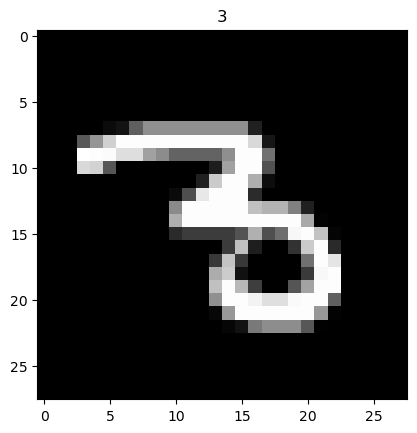

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 18, 18, 18, 126, 136, 175, 26, 166, 255, 247, 127, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30, 36, 94, 154, 170, 253, 253, 253, 253, 253, 225, 172, 253, 242, 195, 64, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 49, 238, 253, 253, 253, 253, 253, 253, 253, 253, 251, 93, 82, 82, 56, 39, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 18, 219, 253, 253, 253, 253, 253, 198, 182, 247, 241, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 80, 156, 107, 253, 253, 205, 11, 0, 43, 154, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 14, 1, 154, 253, 90, 0, 

In [8]:
train_data = datasets.MNIST(
    root = 'data',
    train = True, 
    download=True,
)
#print(dir(train_data)) # check all attributes
#train_data.data[0]
#train_data.targets
plt.imshow(train_data.data[30], cmap='gray')
plt.title('%i' % train_data.targets[30])
plt.show()
print(list(train_data[0][0].getdata())) # print pixels

print(train_data.data[30].shape)


In [9]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,                         
    transform = ToTensor(),  # check difference with and without transform
    download = False,            
)
test_data = datasets.MNIST(
    root = 'data', 
    train = False, 
    transform = ToTensor()
)




torch.Size([1, 28, 28])
torch.Size([28, 28])


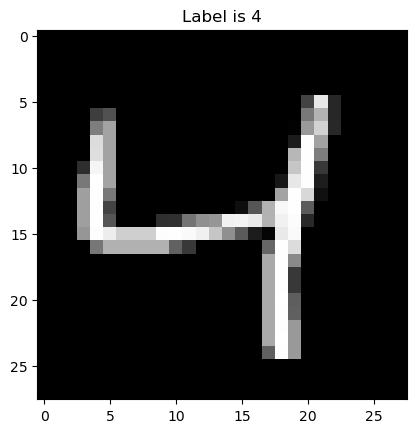

torch.Size([1, 28, 28])

In [10]:
img, label = train_data[2]
print(img.shape) # print pixel
print(img.squeeze().shape) # remove redudant dimensions
plt.imshow(img.permute(1,2,0), cmap='gray')
plt.title(f'Label is {label}' )
plt.show()

img.shape

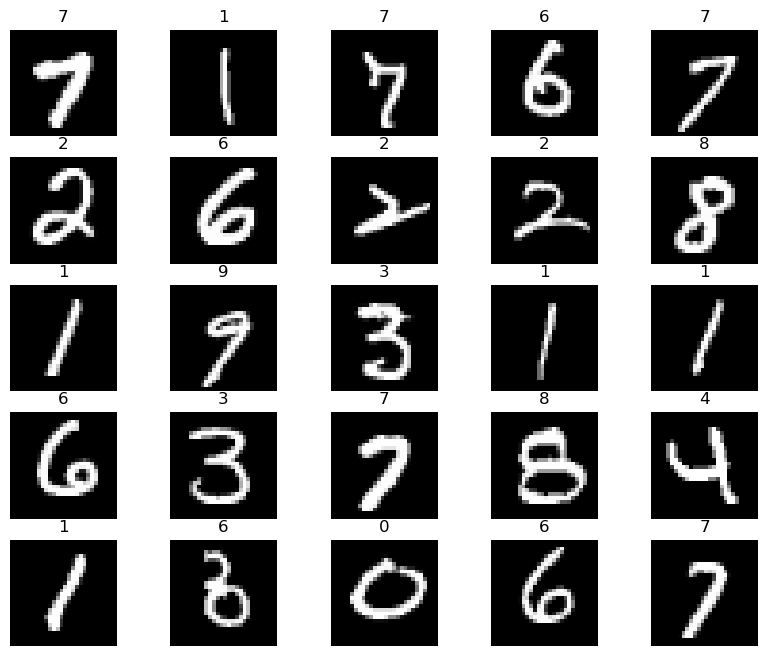

In [14]:
figure = plt.figure(figsize=(10, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [12]:
train_data=data.Subset(train_data, range(3000)) #60000
train_loader=DataLoader(train_data, batch_size=100, shuffle=True)
#for  X_train, y_train in train_loader:
#    X_train, y_train = X_train.to(device), y_train.to(device)

test_data=data.Subset(test_data, range(1000)) #1000
test_loader=DataLoader(test_data, batch_size=100, shuffle=True)

In [13]:
import torch.nn as nn
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(      #   [batch, 1, 28, 28] -> [batch, 16, 14, 14]
            nn.Conv2d(
                in_channels=1,  # greyscale image            
                out_channels=16,   # use 16 kernels        
                kernel_size=5,     # k=5         
                stride=1,           # s=1        
                padding=2,          #  p=2       
            ),                       # [batch, 1, 28, 28] -> [batch, 16, (28+2*2-5)/1+1=28, 28]       
            nn.ReLU(),               # [batch, 16, 28, 28] -> [batch, 16, 28, 28]       
            nn.MaxPool2d(kernel_size=2),  #  [batch, 16, 28, 28] -> [batch, 16, 28/2=14, 14]
        )
        self.conv2 = nn.Sequential(         # [batch, 16, 14, 14] -> [batch, 32, 7, 7]
            nn.Conv2d(16, 32, 5, 1, 2),     # [batch, 16, 14, 14] -> [batch, 32, (14+2*2-5)/1+1=14, 14]
            nn.ReLU(),               #  [batch, 32, 14, 14] -> [batch, 32, 14, 14]       
            nn.MaxPool2d(2),         #  [batch, 32, 14, 14] -> [batch, 32, 14/2=7, 7]    
        )
        # fully connected layer, output 10 classes
        self.out = nn.Linear(32 * 7 * 7, 10) # [batch, 32 * 7 * 7] -> [batch, 10]
    def forward(self, x): # x: [batch, 1, 28, 28]
        x = self.conv1(x) # [batch, 1, 28, 28] -> [batch, 16, 14, 14]
        x = self.conv2(x) # [batch, 16, 14, 14] -> [batch, 32, 7, 7]
        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)       # x.size(0) is the batch size, [batch, 32, 7, 7] -> [batch, 32*7*7]
        output = self.out(x)
        return output

model = CNN()
model.to(device) # model to gpu
batch_x, batch_y=next(iter(test_loader))
batch_x = batch_x.to(device)
print(model(batch_x)[0:3])
myfun=nn.Softmax(dim=1)
myfun(model(batch_x)[0:3])

tensor([[-0.0408, -0.0044, -0.0524,  0.0362,  0.0687, -0.0012, -0.1157, -0.0216,
          0.0189,  0.0408],
        [-0.0253,  0.0835, -0.0519,  0.0507,  0.0687,  0.0324, -0.0818,  0.0194,
          0.0312,  0.0409],
        [-0.0358,  0.0346, -0.0212,  0.1129,  0.0435,  0.0358, -0.1349, -0.0099,
          0.0168,  0.0562]], device='cuda:0', grad_fn=<SliceBackward0>)


tensor([[0.0966, 0.1001, 0.0955, 0.1043, 0.1077, 0.1005, 0.0896, 0.0984, 0.1025,
         0.1048],
        [0.0958, 0.1068, 0.0932, 0.1033, 0.1052, 0.1014, 0.0905, 0.1001, 0.1013,
         0.1023],
        [0.0954, 0.1023, 0.0968, 0.1106, 0.1032, 0.1024, 0.0864, 0.0979, 0.1005,
         0.1045]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [14]:
model = CNN()
model.to(device) # model to gpu
batch_x, batch_y=next(iter(test_loader))
batch_x = batch_x.to(device)
output=model(batch_x)
print(output.shape)
torch.max(output,1)[1]


torch.Size([100, 10])


tensor([1, 1, 1, 0, 1, 1, 1, 6, 0, 1, 6, 6, 1, 6, 1, 1, 6, 6, 6, 6, 0, 0, 6, 1,
        6, 6, 6, 1, 6, 1, 1, 1, 6, 8, 0, 6, 0, 6, 6, 6, 6, 6, 1, 1, 6, 0, 1, 6,
        1, 1, 1, 8, 6, 6, 6, 0, 6, 1, 6, 6, 1, 1, 6, 1, 1, 6, 6, 0, 6, 1, 0, 6,
        1, 6, 0, 0, 6, 0, 1, 0, 0, 1, 1, 1, 1, 6, 8, 1, 0, 0, 6, 1, 1, 6, 6, 0,
        6, 1, 6, 6], device='cuda:0')

In [15]:
from torch import optim
import numpy as np
model = CNN()
model.to(device) # model to gpu

loss_fn = nn.CrossEntropyLoss()   
loss_fn


optimizer = optim.Adam(model.parameters(), lr = 0.01)   
optimizer

# training parameters
n_epochs = 15   # number of epochs to run
 
# Hold the best model
best_acc = 0   # init to 0
history = []
 
# training loop
for epoch in range(n_epochs):
    model.train() # tell pytorch you are training
    for  X_train, y_train in train_loader:
        X_train, y_train = X_train.to(device), y_train.to(device) # data to gpu
        # forward pass
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train) # ypre: [batch, 10], y_train: [batch, 1]
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        # update weights
        optimizer.step()

    model.eval() # tell pytorch you are testing
    with torch.no_grad(): # speed up calculation
        total=0
        accuracy=0
        for  X_test, y_test in test_loader: 
            X_test, y_test = X_test.to(device), y_test.to(device) # data to gpu
            y_pred = model(X_test)
            label_pred = torch.max(y_pred,1)[1] # y_pre: [batch, 10] 
            total = total + len(y_test)
            accuracy = accuracy + (y_test==label_pred).sum()
    history.append([accuracy/total])
    print(f'Epoch {epoch}: {accuracy/total}')
    if accuracy/total > best_acc:
        best_acc = accuracy/total
        torch.save(model, "./gan_mnist_best.model")
        print(f"save with {best_acc}")
    
        

Epoch 0: 0.8970000147819519
save with 0.8970000147819519
Epoch 1: 0.9500000476837158
save with 0.9500000476837158
Epoch 2: 0.9580000638961792
save with 0.9580000638961792
Epoch 3: 0.9630000591278076
save with 0.9630000591278076
Epoch 4: 0.9610000252723694
Epoch 5: 0.9620000720024109
Epoch 6: 0.9590000510215759
Epoch 7: 0.9630000591278076
Epoch 8: 0.9630000591278076
Epoch 9: 0.9670000672340393
save with 0.9670000672340393
Epoch 10: 0.9620000720024109
Epoch 11: 0.9640000462532043
Epoch 12: 0.9620000720024109
Epoch 13: 0.971000075340271
save with 0.971000075340271
Epoch 14: 0.9600000381469727


In [19]:
sample_idx = torch.randint(0, len(test_data), size=(1,)).item()
img = test_data[sample_idx][0]
img_gpu = img.to(device)
img_gpu.shape
img_gpu = torch.unsqueeze(img_gpu, 0) 
img_gpu.shape

torch.Size([1, 1, 28, 28])

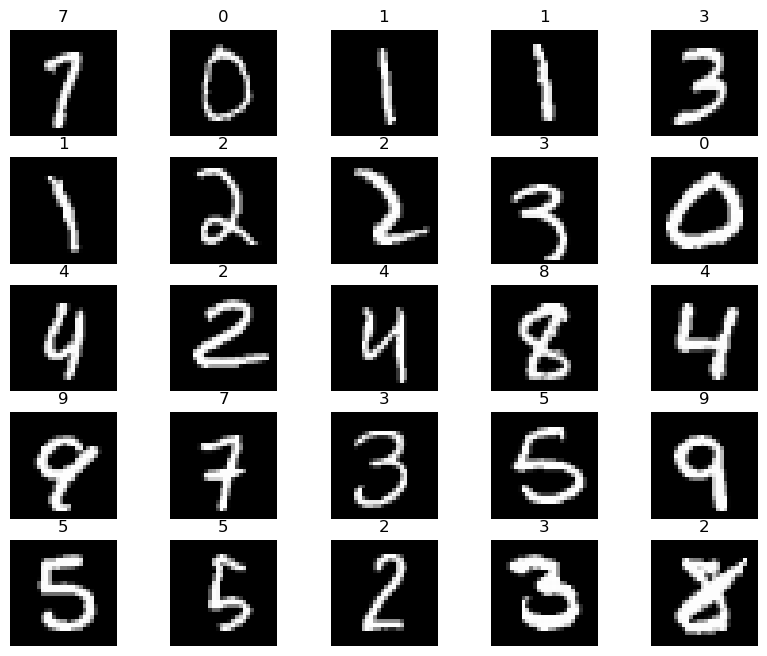

In [20]:
figure = plt.figure(figsize=(10, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(test_data), size=(1,)).item()
    img = test_data[sample_idx][0]
    figure.add_subplot(rows, cols, i)
    img_gpu = img.to(device)
    img_gpu = torch.unsqueeze(img_gpu, 0) # add a new dimension [1, 28, 28] -> [1, 1, 28, 28]
    yhat = model(img_gpu) # [batch, 1, 28, 28] input should be [1, 1, 28, 28]
    #print(yhat)
    label_hat = torch.argmax(yhat) # predicted label
    #print(label_hat)
    #img = img.to(device)
    plt.title(label_hat.data.item())
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()


In [28]:
from PIL import Image 
import torchvision.transforms as transforms 
transform = transforms.Compose([ 
    transforms.PILToTensor() 
]) 
  
# transform = transforms.PILToTensor() 
# Convert the PIL image to Torch tensor 
img_tensor = transform(train_data[0][0]) 
  
# print the converted Torch tensor 
print(img_tensor) 



tensor([[[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
           18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,

torch.Tensor